**Lab 6 - Part 3**

# Task 1: Tải và Tiền xử lý Dữ liệu

In [33]:
# Kiểm tra đường dẫn file dữ liệu
import os
import conllu

# Thử các đường dẫn có thể có
possible_paths = [
    '../../data/lab6/UD_English-EWT/',
    '../../data/UD_English-EWT/',
    '../data/lab6/UD_English-EWT/',
    '../data/UD_English-EWT/',
    './data/lab6/UD_English-EWT/',
    './data/UD_English-EWT/'
]

folder_path = None
for path in possible_paths:
    if os.path.exists(path):
        folder_path = path
        print(f"Tìm thấy thư mục dữ liệu tại: {path}")
        break

if folder_path is None:
    print("Không tìm thấy thư mục dữ liệu. Hãy kiểm tra lại cấu trúc thư mục.")
    print("Thư mục hiện tại:", os.getcwd())
    print("Nội dung thư mục hiện tại:")
    for item in os.listdir('.'):
        print(f"  {item}")
else:
    train_file = folder_path + 'en_ewt-ud-train.conllu'
    dev_file = folder_path + 'en_ewt-ud-dev.conllu'
    test_file = folder_path + 'en_ewt-ud-test.conllu'
    
    # Kiểm tra file có tồn tại không
    for file_name, file_path in [('Train', train_file), ('Dev', dev_file), ('Test', test_file)]:
        if os.path.exists(file_path):
            print(f"✓ {file_name} file: {file_path}")
        else:
            print(f"✗ {file_name} file không tồn tại: {file_path}")


Tìm thấy thư mục dữ liệu tại: ../../data/UD_English-EWT/
✓ Train file: ../../data/UD_English-EWT/en_ewt-ud-train.conllu
✓ Dev file: ../../data/UD_English-EWT/en_ewt-ud-dev.conllu
✓ Test file: ../../data/UD_English-EWT/en_ewt-ud-test.conllu


In [34]:
def load_conllu(file_path):
    """
    Đọc dữ liệu từ file .conllu và trả về danh sách các câu
    
    Args:
        file_path (str): Đường dẫn đến file .conllu
        
    Returns:
        list: Danh sách các câu, mỗi câu là danh sách các cặp (word, upos_tag)
    """
    sentences = []
    
    with open(file_path, 'r', encoding='utf-8') as f:
        data = conllu.parse(f.read())
    
    for sentence in data:
        word_tag_pairs = []
        for token in sentence:
            # Bỏ qua các token có ID phức tạp (như 8-9 trong multiword tokens)
            if isinstance(token['id'], int):
                word = token['form']
                upos_tag = token['upos']
                word_tag_pairs.append((word, upos_tag))
        
        if word_tag_pairs:  # Chỉ thêm câu không rỗng
            sentences.append(word_tag_pairs)
    
    return sentences

# Test hàm load_conllu
print("Đang tải dữ liệu...")
train_sentences = load_conllu(train_file)
dev_sentences = load_conllu(dev_file)
test_sentences = load_conllu(test_file)

print(f"Số câu trong tập train: {len(train_sentences)}")
print(f"Số câu trong tập dev: {len(dev_sentences)}")
print(f"Số câu trong tập test: {len(test_sentences)}")

# Hiển thị một số ví dụ
print("\nVí dụ câu đầu tiên trong tập train:")
print(train_sentences[0][:10])  # Chỉ hiển thị 10 từ đầu tiên

Đang tải dữ liệu...
Số câu trong tập train: 12544
Số câu trong tập dev: 2001
Số câu trong tập test: 2077

Ví dụ câu đầu tiên trong tập train:
[('Al', 'PROPN'), ('-', 'PUNCT'), ('Zaman', 'PROPN'), (':', 'PUNCT'), ('American', 'ADJ'), ('forces', 'NOUN'), ('killed', 'VERB'), ('Shaikh', 'PROPN'), ('Abdullah', 'PROPN'), ('al', 'PROPN')]
Số câu trong tập train: 12544
Số câu trong tập dev: 2001
Số câu trong tập test: 2077

Ví dụ câu đầu tiên trong tập train:
[('Al', 'PROPN'), ('-', 'PUNCT'), ('Zaman', 'PROPN'), (':', 'PUNCT'), ('American', 'ADJ'), ('forces', 'NOUN'), ('killed', 'VERB'), ('Shaikh', 'PROPN'), ('Abdullah', 'PROPN'), ('al', 'PROPN')]


In [35]:
def build_vocabulary(train_sentences):
    """
    Xây dựng từ điển từ dữ liệu huấn luyện
    
    Args:
        train_sentences (list): Danh sách các câu từ tập train
        
    Returns:
        tuple: (word_to_ix, tag_to_ix) - hai từ điển ánh xạ
    """
    # Tập hợp tất cả các từ và tags
    all_words = set()
    all_tags = set()
    
    for sentence in train_sentences:
        for word, tag in sentence:
            all_words.add(word)
            all_tags.add(tag)
    
    # Tạo word_to_ix với <UNK> token đặc biệt
    word_to_ix = {'<UNK>': 0}
    for word in sorted(all_words):  # Sắp xếp để đảm bảo consistent indexing
        word_to_ix[word] = len(word_to_ix)
    
    # Tạo tag_to_ix
    tag_to_ix = {}
    for tag in sorted(all_tags):  # Sắp xếp để đảm bảo consistent indexing
        tag_to_ix[tag] = len(tag_to_ix)
    
    return word_to_ix, tag_to_ix

# Xây dựng từ điển từ dữ liệu train
print("Đang xây dựng từ điển...")
word_to_ix, tag_to_ix = build_vocabulary(train_sentences)

print(f"\nKích thước từ điển từ (word_to_ix): {len(word_to_ix)}")
print(f"Kích thước từ điển nhãn (tag_to_ix): {len(tag_to_ix)}")

print(f"\nCác nhãn UPOS có trong dữ liệu:")
for tag, idx in sorted(tag_to_ix.items(), key=lambda x: x[1]):
    print(f"  {tag}: {idx}")

print(f"\nMột số từ đầu tiên trong từ điển:")
for i, (word, idx) in enumerate(sorted(word_to_ix.items(), key=lambda x: x[1])[:10]):
    print(f"  {word}: {idx}")

print("...")
print(f"Tổng số từ (bao gồm <UNK>): {len(word_to_ix)}")

Đang xây dựng từ điển...

Kích thước từ điển từ (word_to_ix): 19674
Kích thước từ điển nhãn (tag_to_ix): 17

Các nhãn UPOS có trong dữ liệu:
  ADJ: 0
  ADP: 1
  ADV: 2
  AUX: 3
  CCONJ: 4
  DET: 5
  INTJ: 6
  NOUN: 7
  NUM: 8
  PART: 9
  PRON: 10
  PROPN: 11
  PUNCT: 12
  SCONJ: 13
  SYM: 14
  VERB: 15
  X: 16

Một số từ đầu tiên trong từ điển:
  <UNK>: 0
  !: 1
  !!: 2
  !!!: 3
  !!!!: 4
  !!!!!: 5
  !!!!!!: 6
  !!!!!!!: 7
  !!!!!!!!!!: 8
  !!!!!!!!!!!: 9
...
Tổng số từ (bao gồm <UNK>): 19674


In [36]:
# Hash-based vocabulary tương tự BigDL Scala code
import hashlib

def hash_word(word, vocab_size=16384):
    """
    Hash một từ thành index sử dụng hash function tương tự Murmur3
    
    Args:
        word (str): Từ cần hash
        vocab_size (int): Kích thước vocabulary
        
    Returns:
        int: Hash index từ 1 đến vocab_size (0 reserved cho padding)
    """
    # Sử dụng hashlib để tạo hash tương tự Murmur3
    hash_object = hashlib.md5(word.encode('utf-8'))
    hash_hex = hash_object.hexdigest()
    hash_int = int(hash_hex, 16)
    
    # Modulo để đảm bảo trong khoảng vocab_size, +1 để tránh index 0 (reserved cho padding)
    return (hash_int % (vocab_size - 1)) + 1

def build_vocabulary(train_sentences, vocab_size=16384):
    """
    Xây dựng hash-based vocabulary tương tự BigDL
    
    Args:
        train_sentences (list): Danh sách các câu từ tập train
        vocab_size (int): Kích thước vocabulary (default: 16384 như Scala code)
        
    Returns:
        tuple: (hash_word_func, tag_to_ix) - hàm hash và từ điển tags
    """
    # Tập hợp tất cả các tags
    all_tags = set()
    
    for sentence in train_sentences:
        for word, tag in sentence:
            all_tags.add(tag)
    
    # Tạo tag_to_ix (giữ nguyên như trước, bắt đầu từ 0)
    tag_to_ix = {}
    for tag in sorted(all_tags):
        tag_to_ix[tag] = len(tag_to_ix)
    
    # Tạo hàm hash cho từ
    def hash_word_func(word):
        return hash_word(word, vocab_size)
    
    return hash_word_func, tag_to_ix, vocab_size

# Test hash-based vocabulary
print("Xây dựng hash-based vocabulary...")
hash_word_func, tag_to_ix_hash, VOCAB_SIZE_HASH = build_vocabulary(train_sentences, vocab_size=16384)

print(f"\nHash-based vocabulary:")
print(f"  - Vocabulary size: {VOCAB_SIZE_HASH}")
print(f"  - Tag dictionary size: {len(tag_to_ix_hash)}")

# Test hash function với một số từ
test_words = ["the", "quick", "brown", "fox", "jumps", "over", "lazy", "dog"]
print(f"\nTest hash function:")
for word in test_words:
    hash_idx = hash_word_func(word)
    print(f"  '{word}' -> {hash_idx}")

# Kiểm tra tính nhất quán của hash
print(f"\nTính nhất quán của hash function:")
for word in test_words[:3]:
    hash1 = hash_word_func(word)
    hash2 = hash_word_func(word)
    print(f"  '{word}': {hash1} == {hash2} -> {hash1 == hash2}")

print(f"\nCác nhãn UPOS (hash-based):")
for tag, idx in sorted(tag_to_ix_hash.items(), key=lambda x: x[1]):
    print(f"  {tag}: {idx}")

Xây dựng hash-based vocabulary...

Hash-based vocabulary:
  - Vocabulary size: 16384
  - Tag dictionary size: 17

Test hash function:
  'the' -> 6087
  'quick' -> 4399
  'brown' -> 3508
  'fox' -> 5816
  'jumps' -> 16315
  'over' -> 15485
  'lazy' -> 14630
  'dog' -> 9240

Tính nhất quán của hash function:
  'the': 6087 == 6087 -> True
  'quick': 4399 == 4399 -> True
  'brown': 3508 == 3508 -> True

Các nhãn UPOS (hash-based):
  ADJ: 0
  ADP: 1
  ADV: 2
  AUX: 3
  CCONJ: 4
  DET: 5
  INTJ: 6
  NOUN: 7
  NUM: 8
  PART: 9
  PRON: 10
  PROPN: 11
  PUNCT: 12
  SCONJ: 13
  SYM: 14
  VERB: 15
  X: 16


In [37]:
# Tạo hàm helper để chuyển đổi câu thành indices
def sentence_to_indices(sentence, word_to_ix, tag_to_ix):
    """
    Chuyển đổi một câu thành danh sách các indices
    
    Args:
        sentence (list): Danh sách các cặp (word, tag)
        word_to_ix (dict): Từ điển ánh xạ từ -> index
        tag_to_ix (dict): Từ điển ánh xạ tag -> index
    
    Returns:
        tuple: (word_indices, tag_indices)
    """
    word_indices = []
    tag_indices = []
    
    for word, tag in sentence:
        # Sử dụng <UNK> nếu từ không có trong từ điển
        word_idx = word_to_ix.get(word, word_to_ix['<UNK>'])
        tag_idx = tag_to_ix[tag]
        
        word_indices.append(word_idx)
        tag_indices.append(tag_idx)
    
    return word_indices, tag_indices

# Test với một câu ví dụ
example_sentence = train_sentences[0]
print("Câu ví dụ (5 từ đầu):")
print(example_sentence[:5])

word_ids, tag_ids = sentence_to_indices(example_sentence, word_to_ix, tag_to_ix)
print("\nWord indices (5 đầu):")
print(word_ids[:5])
print("\nTag indices (5 đầu):")
print(tag_ids[:5])

# Kiểm tra reverse mapping
print("\nKiểm tra reverse mapping:")
ix_to_word = {idx: word for word, idx in word_to_ix.items()}
ix_to_tag = {idx: tag for tag, idx in tag_to_ix.items()}

for i in range(min(5, len(word_ids))):
    original_word, original_tag = example_sentence[i]
    reconstructed_word = ix_to_word[word_ids[i]]
    reconstructed_tag = ix_to_tag[tag_ids[i]]
    print(f"  '{original_word}'/'{original_tag}' -> {word_ids[i]}/{tag_ids[i]} -> '{reconstructed_word}'/'{reconstructed_tag}'")

Câu ví dụ (5 từ đầu):
[('Al', 'PROPN'), ('-', 'PUNCT'), ('Zaman', 'PROPN'), (':', 'PUNCT'), ('American', 'ADJ')]

Word indices (5 đầu):
[1361, 81, 7684, 1127, 1416]

Tag indices (5 đầu):
[11, 12, 11, 12, 0]

Kiểm tra reverse mapping:
  'Al'/'PROPN' -> 1361/11 -> 'Al'/'PROPN'
  '-'/'PUNCT' -> 81/12 -> '-'/'PUNCT'
  'Zaman'/'PROPN' -> 7684/11 -> 'Zaman'/'PROPN'
  ':'/'PUNCT' -> 1127/12 -> ':'/'PUNCT'
  'American'/'ADJ' -> 1416/0 -> 'American'/'ADJ'


In [38]:
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from tqdm import tqdm   

# Task 2: Tạo PyTorch Dataset và DataLoader

In [39]:
class POSDataset(Dataset):
    
    def __init__(self, sentences, hash_word_func, tag_to_ix):

        self.sentences = sentences
        self.hash_word_func = hash_word_func
        self.tag_to_ix = tag_to_ix
    
    def __len__(self):
        """
        Trả về tổng số câu trong dataset
        """
        return len(self.sentences)
    
    def __getitem__(self, idx):
        """
        Lấy một mẫu dữ liệu tại index idx.
        Trả về các Tensor có độ dài thực của câu.
        
        Args:
            idx (int): Index của câu cần lấy
            
        Returns:
            tuple: (sentence_tensor, tag_tensor) - độ dài thực của câu
        """
        sentence_data = self.sentences[idx]
        
        word_indices = []
        tag_indices = []
        
        for word, tag in sentence_data:
            # Ánh xạ từ (sử dụng băm)
            word_indices.append(self.hash_word_func(word))
            # Ánh xạ nhãn (sử dụng từ điển)
            tag_indices.append(self.tag_to_ix[tag])
            
        # Chuyển thành tensors
        sentence_tensor = torch.tensor(word_indices, dtype=torch.long)
        tag_tensor = torch.tensor(tag_indices, dtype=torch.long)
        
        return sentence_tensor, tag_tensor

# Test lớp POSDataset
print("Tạo hash-based datasets...")
train_dataset_hash = POSDataset(train_sentences, hash_word_func, tag_to_ix_hash)
dev_dataset_hash = POSDataset(dev_sentences, hash_word_func, tag_to_ix_hash)
test_dataset_hash = POSDataset(test_sentences, hash_word_func, tag_to_ix_hash)

print(f"Hash-based datasets:")
print(f"  - Train dataset size: {len(train_dataset_hash)}")
print(f"  - Dev dataset size: {len(dev_dataset_hash)}")
print(f"  - Test dataset size: {len(test_dataset_hash)}")

# Test __getitem__
sample_idx = 0
sentence_tensor, tag_tensor = train_dataset_hash[sample_idx]
print(f"\nMẫu thứ {sample_idx} (fixed-length):")
print(f"  - Sentence tensor shape: {sentence_tensor.shape}")
print(f"  - Tag tensor shape: {tag_tensor.shape}")
print(f"  - Sentence indices (first 15): {sentence_tensor[:15]}")
print(f"  - Tag indices (first 15): {tag_tensor[:15]}")
print(f"  - Sentence indices (last 10): {sentence_tensor[-10:]}")  # Kiểm tra padding
print(f"  - Tag indices (last 10): {tag_tensor[-10:]}")  # Kiểm tra padding

Tạo hash-based datasets...
Hash-based datasets:
  - Train dataset size: 12544
  - Dev dataset size: 2001
  - Test dataset size: 2077

Mẫu thứ 0 (fixed-length):
  - Sentence tensor shape: torch.Size([29])
  - Tag tensor shape: torch.Size([29])
  - Sentence indices (first 15): tensor([ 6681, 11715,  4541, 16279,  3509,   197,   410,  5709,  4642,  1585,
        11715,   207, 13427,  6087, 14243])
  - Tag indices (first 15): tensor([11, 12, 11, 12,  0,  7, 15, 11, 11, 11, 12, 11, 12,  5,  7])
  - Sentence indices (last 10): tensor([ 6087, 13451,   246,  3848, 13427,  5801,  6087, 15717, 12972, 12034])
  - Tag indices (last 10): tensor([ 5,  7,  1, 11, 12,  1,  5,  0,  7, 12])


In [40]:
def collate_fn(batch):
    PAD_INDEX = 0      # Chỉ số Padding cho từ
    TAG_PAD_INDEX = -1 # Chỉ số Padding cho nhãn
    # Tách các Tensors từ và Tensors nhãn
    sentence_tensors = [item[0] for item in batch]
    tag_tensors = [item[1] for item in batch]

    padded_sentences = pad_sequence(
        sentence_tensors, 
        batch_first=True, 
        padding_value=PAD_INDEX
    )
    
    # Padding cho nhãn (dùng TAG_PAD_INDEX)
    padded_tags = pad_sequence(
        tag_tensors, 
        batch_first=True, 
        padding_value=TAG_PAD_INDEX
    )

    return padded_sentences, padded_tags

# Tạo DataLoaders với hash-based dataset
batch_size = 32

train_loader = DataLoader(
    train_dataset_hash, 
    batch_size=batch_size, 
    shuffle=True, 
    collate_fn=collate_fn
)

dev_loader = DataLoader(
    dev_dataset_hash, 
    batch_size=batch_size, 
    shuffle=False, 
    collate_fn=collate_fn
)

test_loader = DataLoader(
    test_dataset_hash, 
    batch_size=batch_size, 
    shuffle=False, 
    collate_fn=collate_fn
)

print(f"Hash-based DataLoaders:")
print(f"  - Train batches: {len(train_loader)}")
print(f"  - Dev batches: {len(dev_loader)}")
print(f"  - Test batches: {len(test_loader  )}")

# Test một batch
print("\nTest batch từ hash-based train_loader:")
for batch_idx, (sentences, tags) in enumerate(train_loader):
    print(f"  - Batch shape - Sentences: {sentences.shape}, Tags: {tags.shape}")
    print(f"  - Sentences sample (first 5 of first sample): {sentences[0][:5]}")
    print(f"  - Tags sample (first 5 of first sample): {tags[0][:5]}")
    print(f"  - Check padding (last 5 of first sample):")
    print(f"    * Sentences: {sentences[0][-5:]}")
    print(f"    * Tags: {tags[0][-5:]}")
    break  # Chỉ test batch đầu tiên

Hash-based DataLoaders:
  - Train batches: 392
  - Dev batches: 63
  - Test batches: 65

Test batch từ hash-based train_loader:
  - Batch shape - Sentences: torch.Size([32, 41]), Tags: torch.Size([32, 41])
  - Sentences sample (first 5 of first sample): tensor([5240,    0,    0,    0,    0])
  - Tags sample (first 5 of first sample): tensor([11, -1, -1, -1, -1])
  - Check padding (last 5 of first sample):
    * Sentences: tensor([0, 0, 0, 0, 0])
    * Tags: tensor([-1, -1, -1, -1, -1])


# Task 3: Xây dựng Mô hình RNN

In [64]:
class SimpleRNNForTokenClassification(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_tags,
                 num_layers=1, dropout=0.3):
        super().__init__()
        
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)

        self.rnn = nn.RNN(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0
        )

        self.layernorm = nn.LayerNorm(hidden_dim * 2)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_dim * 2, num_tags)

        self._init_weights()

    def _init_weights(self):
        nn.init.normal_(self.embedding.weight, mean=0.0, std=0.05)
        for name, param in self.rnn.named_parameters():
            if "weight" in name:
                nn.init.xavier_uniform_(param)
            elif "bias" in name:
                nn.init.constant_(param, 0)
        nn.init.xavier_uniform_(self.classifier.weight)
        nn.init.constant_(self.classifier.bias, 0)

    def forward(self, x):
        x = self.embedding(x)
        out, _ = self.rnn(x)
        out = self.layernorm(out)
        out = self.dropout(out)
        return self.classifier(out)


VOCAB_SIZE = VOCAB_SIZE_HASH  
EMBEDDING_DIM = 100
HIDDEN_DIM = 64
NUM_TAGS = len(tag_to_ix_hash) 

model_simple = SimpleRNNForTokenClassification(
    vocab_size=VOCAB_SIZE,
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    num_tags=NUM_TAGS
)

total_params = sum(p.numel() for p in model_simple.parameters())
print(f"Model created: {total_params:,} parameters")

# Quick test
test_input = torch.randint(0, VOCAB_SIZE, (2, 5))
model_simple.eval()
with torch.no_grad():
    output = model_simple(test_input)
    print(f"Test passed: {test_input.shape} -> {output.shape}")

Model created: 1,662,097 parameters
Test passed: torch.Size([2, 5]) -> torch.Size([2, 5, 17])


# Task 4: Huấn luyện mô hình

In [65]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

model = model_simple.to(device)
print("Using SimpleRNNForTokenClassification")

learning_rate = 1e-4
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
criterion = nn.CrossEntropyLoss(ignore_index=-1)
num_epochs = 10


def train_model(model, train_loader, dev_loader, optimizer, criterion, device, num_epochs=10):
    try:
        from torch.utils.tensorboard import SummaryWriter
        import datetime
        log_dir = f"runs/simple_pos_tagger_{datetime.datetime.now().strftime('%Y%m%d-%H%M%S')}"
        writer = SummaryWriter(log_dir)
        tensorboard_available = True
        print(f"TensorBoard log dir: {log_dir}")
    except ImportError:
        writer = None
        tensorboard_available = False
        print("TensorBoard not available")

    print(f"Training for {num_epochs} epochs on device: {device}")
    print(f"Optimizer: {optimizer.__class__.__name__}")
    total_params = sum(p.numel() for p in model.parameters())
    print(f"Total parameters: {total_params}")

    model.train()
    global_step = 0

    for epoch in range(1, num_epochs + 1):
        epoch_loss = 0.0

        for sentences, tags in train_loader:
            sentences, tags = sentences.to(device), tags.to(device)

            optimizer.zero_grad()
            logits = model(sentences)

            batch_size, seq_len, num_tags = logits.shape
            loss = criterion(
                logits.view(batch_size * seq_len, num_tags),
                tags.view(batch_size * seq_len)
            )
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

            if tensorboard_available and global_step % 50 == 0:
                writer.add_scalar('Loss/Train_step', loss.item(), global_step)

            global_step += 1

        avg_loss = epoch_loss / len(train_loader)
        print(f"Epoch {epoch}/{num_epochs} - Train Loss: {avg_loss:.4f}")

        if tensorboard_available:
            writer.add_scalar('Loss/Train_epoch', avg_loss, epoch)
            # Evaluate on dev
            dev_acc, dev_loss = evaluate_model(model, dev_loader, device, criterion)
            writer.add_scalar('Accuracy/Dev', dev_acc, epoch)
            writer.add_scalar('Loss/Dev', dev_loss, epoch)
            print(f"  Dev accuracy: {dev_acc:.4f}, Dev loss: {dev_loss:.4f}")

    # Save model
    torch.save(model.state_dict(), 'pos_tagger_model.pth')
    print("Model saved: pos_tagger_model.pth")

    if tensorboard_available:
        writer.close()
        print(f"TensorBoard logs written to: {log_dir}")
        print(f"Run: tensorboard --logdir=runs")

    return model


Device: cpu
Using SimpleRNNForTokenClassification


# Task 5: Đánh giá Mô hình

In [60]:
def evaluate_model(model, dataloader, device, criterion):
    model.eval()
    
    total_correct = 0
    total_tokens = 0
    total_loss = 0
    total_batches = 0
    
    with torch.no_grad():
        for sentences, tags in dataloader:
            sentences, tags = sentences.to(device), tags.to(device)
            logits = model(sentences)

            # Loss
            batch_size, seq_len, num_tags = logits.shape
            logits_flat = logits.view(batch_size * seq_len, num_tags)
            tags_flat = tags.view(batch_size * seq_len)
            loss = criterion(logits_flat, tags_flat)

            total_loss += loss.item()
            total_batches += 1

            # Accuracy (ignore padding)
            preds = logits.argmax(dim=-1)
            mask = (tags != -1)
            total_correct += (preds[mask] == tags[mask]).sum().item()
            total_tokens += mask.sum().item()
    
    acc = total_correct / total_tokens if total_tokens > 0 else 0
    avg_loss = total_loss / total_batches if total_batches > 0 else 0

    model.train()
    return acc, avg_loss


In [44]:
# Mở TensorBoard trong notebook
# Lưu ý: Chạy cell này TRONG QUÁ TRÌNH hoặc SAU KHI huấn luyện để xem real-time metrics

# Cách 1: Sử dụng magic command (khuyến nghị)
#%load_ext tensorboard
#%tensorboard --logdir=runs

# Cách 2: Nếu magic command không hoạt động, sử dụng code này:
# import subprocess
# subprocess.Popen(['tensorboard', '--logdir=runs', '--port=6006'])
# print("TensorBoard đã khởi động tại: http://localhost:6006")

# Cách 3: Inline TensorBoard widget (nếu có Jupyter extension)
# Mở TensorBoard trong notebook bằng inline widget
%load_ext tensorboard
from tensorboard import notebook
notebook.display(port=6006, height=800)


The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard
Selecting TensorBoard with logdir runs (started 0:52:38 ago; port 6006, pid 21472).


In [66]:
# Train and evaluate the model
print("=== TRAINING POS TAGGER ===")
trained_model = train_model(model, train_loader, dev_loader, optimizer, criterion, device, num_epochs)

print("\n=== FINAL EVALUATION ===")
# Final evaluation on test set
test_acc, test_loss = evaluate_model(trained_model, test_loader, device, criterion)
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

# Final evaluation on dev set
dev_acc, dev_loss = evaluate_model(trained_model, dev_loader, device, criterion)
print(f"Dev Accuracy: {dev_acc:.4f}")
print(f"Dev Loss: {dev_loss:.4f}")

=== TRAINING POS TAGGER ===
TensorBoard log dir: runs/simple_pos_tagger_20251118-125055
Training for 10 epochs on device: cpu
Optimizer: Adam
Total parameters: 1662097
Epoch 1/10 - Train Loss: 2.5302
Epoch 1/10 - Train Loss: 2.5302
  Dev accuracy: 0.5557, Dev loss: 1.5276
  Dev accuracy: 0.5557, Dev loss: 1.5276
Epoch 2/10 - Train Loss: 1.1990
Epoch 2/10 - Train Loss: 1.1990
  Dev accuracy: 0.7551, Dev loss: 0.8148
  Dev accuracy: 0.7551, Dev loss: 0.8148
Epoch 3/10 - Train Loss: 0.7233
Epoch 3/10 - Train Loss: 0.7233
  Dev accuracy: 0.8112, Dev loss: 0.6090
  Dev accuracy: 0.8112, Dev loss: 0.6090
Epoch 4/10 - Train Loss: 0.5285
Epoch 4/10 - Train Loss: 0.5285
  Dev accuracy: 0.8388, Dev loss: 0.5169
  Dev accuracy: 0.8388, Dev loss: 0.5169
Epoch 5/10 - Train Loss: 0.4203
Epoch 5/10 - Train Loss: 0.4203
  Dev accuracy: 0.8540, Dev loss: 0.4729
  Dev accuracy: 0.8540, Dev loss: 0.4729
Epoch 6/10 - Train Loss: 0.3495
Epoch 6/10 - Train Loss: 0.3495
  Dev accuracy: 0.8624, Dev loss: 0.44

In [70]:
def predict_sentence(sentence):
    """Dự đoán POS tags cho câu mới"""
    if 'trained_model' not in globals():
        print("Model chưa được train!")
        return []
    
    import re
    # Tokenize
    sentence = re.sub(r'([.!?,:;"])', r' \1 ', sentence)
    tokens = sentence.split()
    
    if not tokens:
        return []
    
    # Hash và padding
    word_indices = [hash_word_func(token) for token in tokens]
    MAX_SEQ_LEN = 50
    word_indices += [0] * (MAX_SEQ_LEN - len(word_indices))
    
    # Predict
    ix_to_tag = {idx: tag for tag, idx in tag_to_ix_hash.items()}
    input_tensor = torch.tensor([word_indices]).to(device)
    
    trained_model.eval()
    with torch.no_grad():
        logits = trained_model(input_tensor)
        predictions = logits.argmax(dim=-1)[0]
    
    # Kết quả
    results = []
    for i, token in enumerate(tokens):
        if i < MAX_SEQ_LEN:
            tag = ix_to_tag[predictions[i].item()]
            results.append((token, tag))
    
    return results


sentence = "The cat is sleeping."
results = predict_sentence(sentence)
print(f"Câu: {sentence}")
for word, tag in results:
    print(f"  ({word} : {tag})")


Câu: The cat is sleeping.
  (The : DET)
  (cat : NOUN)
  (is : AUX)
  (sleeping : VERB)
  (. : PUNCT)


Classification report:

              precision    recall  f1-score   support

         ADJ     0.7628    0.7594    0.7611      1787
         ADP     0.8772    0.9169    0.8966      2033
         ADV     0.7819    0.8005    0.7911      1178
         AUX     0.9185    0.9572    0.9375      1543
       CCONJ     0.9932    0.9864    0.9898       737
         DET     0.9666    0.9615    0.9641      1897
        INTJ     0.8387    0.6500    0.7324       120
        NOUN     0.7747    0.8228    0.7980      4137
         NUM     0.7339    0.5904    0.6544       542
        PART     0.8487    0.9507    0.8968       649
        PRON     0.9336    0.9505    0.9420      2161
       PROPN     0.7036    0.5899    0.6418      1980
       PUNCT     0.9848    0.9835    0.9842      3096
       SCONJ     0.7086    0.6016    0.6507       384
         SYM     0.7670    0.7248    0.7453       109
        VERB     0.8040    0.8376    0.8205      2605
           X     0.5833    0.0515    0.0946       136

  

,ADJ,ADP,ADV,AUX,CCONJ,DET,INTJ,NOUN,NUM,PART,PRON,PROPN,PUNCT,SCONJ,SYM,VERB,X
ADJ,1357,11,61,0,0,3,7,176,16,4,2,58,3,0,2,87,0
ADP,3,1864,30,1,1,0,0,11,1,88,1,4,2,22,0,5,0
ADV,63,62,943,1,3,15,3,32,1,4,7,8,0,15,0,21,0
AUX,0,0,0,1477,0,0,0,3,2,3,1,3,0,0,0,54,0
CCONJ,0,2,1,1,727,0,0,2,0,0,0,2,0,1,0,1,0
DET,4,0,3,0,1,1824,0,2,0,0,58,0,0,4,0,1,0
INTJ,5,4,8,0,0,8,78,7,1,0,1,6,1,0,0,1,0
NOUN,156,24,53,10,0,1,1,3404,37,0,25,246,4,3,1,172,0
NUM,20,1,2,7,0,2,2,80,320,0,5,63,4,1,1,34,0
PART,0,25,0,1,0,0,0,1,0,617,0,0,3,0,0,2,0


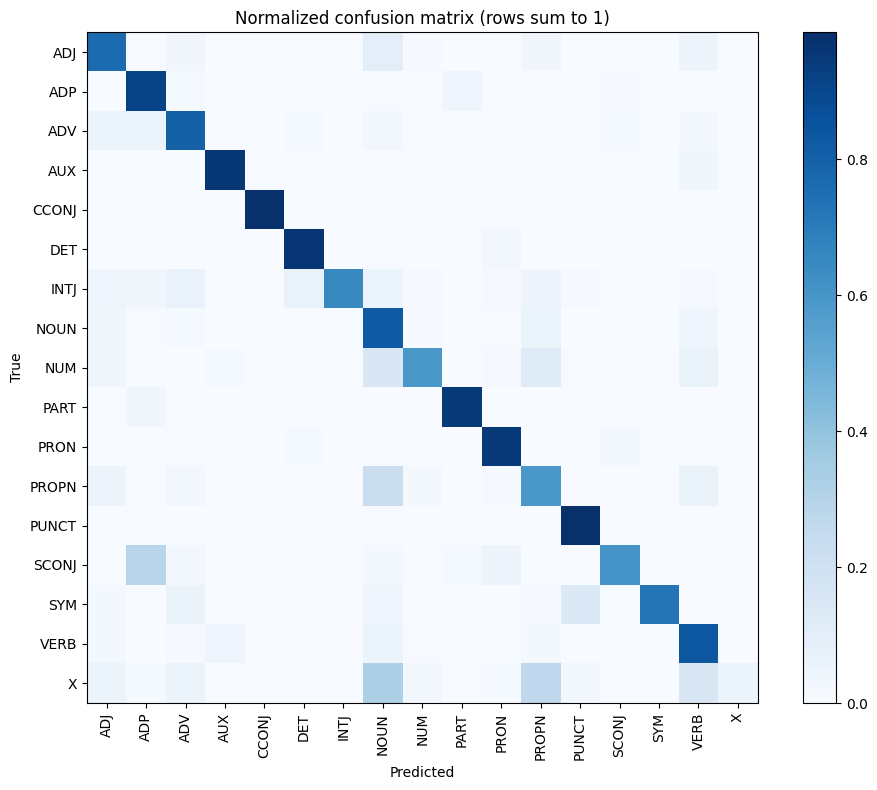

In [63]:
from sklearn.metrics import confusion_matrix, classification_report
import pandas as pd
import numpy as np
from IPython.display import display

# Tính confusion matrix và bảng đánh giá trên test set
import matplotlib.pyplot as plt

model = trained_model.to(device)
model.eval()

y_true = []
y_pred = []
with torch.no_grad():
    for sentences, tags in test_loader:
        sentences = sentences.to(device)
        tags = tags.to(device)
        logits = model(sentences)
        preds = logits.argmax(dim=-1)
        mask = (tags != -1)
        if mask.sum().item() == 0:
            continue
        y_true.extend(tags[mask].view(-1).cpu().tolist())
        y_pred.extend(preds[mask].view(-1).cpu().tolist())

# Chuẩn bị nhãn theo thứ tự index
labels = sorted(ix_to_tag.keys())
tag_names = [ix_to_tag[i] for i in labels]

# Bảng báo cáo (precision/recall/f1)
print("Classification report:\n")
print(classification_report(y_true, y_pred, labels=labels, target_names=tag_names, digits=4))

# Confusion matrix (counts) dưới dạng DataFrame
cm = confusion_matrix(y_true, y_pred, labels=labels)
cm_df = pd.DataFrame(cm, index=tag_names, columns=tag_names)
print("\nConfusion matrix (counts):")
display(cm_df)

# Confusion matrix normalized theo hàng (true labels)
with np.errstate(all='ignore'):
    cm_norm = cm.astype(float) / cm.sum(axis=1)[:, None]
cm_norm = np.nan_to_num(cm_norm)
cm_norm_df = pd.DataFrame(cm_norm, index=tag_names, columns=tag_names)

# Vẽ heatmap đơn giản
plt.figure(figsize=(10, 8))
plt.imshow(cm_norm_df, interpolation='nearest', cmap='Blues')
plt.title('Normalized confusion matrix (rows sum to 1)')
plt.colorbar()
ticks = np.arange(len(tag_names))
plt.xticks(ticks, tag_names, rotation=90)
plt.yticks(ticks, tag_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()